# Imports 

In [55]:
import os
import re
import csv
import zipfile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    KFold,
    cross_val_score,
)
import math
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import statistics

# Functions

In [3]:
def shift_quarter_back(quarter_code: str, n_quarters_back: int) -> str:
    """
    Given a quarter code like "2020 Q1" and a non-negative integer n_quarters_back,
    return the quarter code that is n_quarters_back quarters earlier.
    e.g. shift_quarter_back("2020 Q1", 1) -> "2019 Q4"
    """

    # parse
    try:
        year_str, q_str = quarter_code.strip().split()
        year = int(year_str)
        if not q_str.upper().startswith("Q"):
            raise ValueError(f"Invalid quarter part: {q_str}")
        quarter = int(q_str.upper().replace("Q", ""))
        if quarter < 1 or quarter > 4:
            raise ValueError(f"Quarter must be between 1 and 4, got {quarter}")
    except Exception as e:
        raise ValueError(
            f"Invalid quarter_code format '{quarter_code}'. Expected 'YYYY Qn'. Error: {e}"
        )

    # convert to a "quarter index" since some origin, e.g. 0-based or 1-based
    # Let's convert to a zero-based index: total_quarters = year * 4 + (quarter - 1)
    total_quarters = year * 4 + (quarter - 1)

    # subtract
    new_total = total_quarters - n_quarters_back
    if new_total < 0:
        raise ValueError(
            f"Resulting quarter is before year 0: n_quarters_back={n_quarters_back} too large"
        )

    # convert back
    new_year = new_total // 4
    new_quarter = (new_total % 4) + 1

    return f"{new_year} Q{new_quarter}"

# Datasets

In [4]:
path = "../../Data_Processing/outputs/banks_y9c"

In [5]:
df_9c = pd.concat(
    [
        pd.read_pickle(os.path.join(path, file))
        for file in os.listdir(path)
        # if "df_banks_part_" in file
    ],
    axis=0,
).reset_index(drop=True)

## Target variable definition

In [6]:
df_9c_sorted = df_9c[
    sorted(df_9c.columns, key=lambda c: (not c[0].islower(), c.lower(), c))
].sort_values(by=["id", "quarter"])

In [7]:
def value_x_quarters_before(
    df: pd.DataFrame, quarter: str, nr_quarters_before: int, value_col: str
):
    """
    Returns the values x quarters before a target quarter for any given column.

    Parameters:
        df (pd.DataFrame): DataFrame with columns ['id', 'year', 'nr_quarter', ...].
        quarter (str): Target quarter YYYYMMDD.
        nr_quarters_before (int): Number of quarters to go back.
        value_col (str): Name of the column to retrieve values for.

    Returns:
        pd.list_shift_quarters_for_growthFrame: list_shift_quarters_for_growthFrame with columns ['id', 'year', 'nr_quarter', f'{value_col}_x_quarters_before']
    """

    # target_year = int(quarter[:4])
    # target_month = int(quarter[4:6])
    # target_quarter = ((target_month - 1) // 3) + 1

    # # Compute the target quarter’s "absolute quarter number"
    # target_abs_quarter = target_year * 4 + target_quarter

    # # Compute the quarter to look for
    # desired_abs_quarter = target_abs_quarter - nr_quarters_before

    # # Convert abs_quarter back to year and quarter
    # desired_year = desired_abs_quarter // 4
    # desired_quarter = desired_abs_quarter % 4
    # if desired_quarter == 0:
    #     desired_year -= 1
    #     desired_quarter = 4

    quarter_shifted_ = shift_quarter_back(quarter, nr_quarters_before)

    # Filter for desired quarter
    result = df[
        # (df["year"] == desired_year) & (df["nr_quarter"] == desired_quarter)
        (df["quarter_code"] == quarter_shifted_)
    ].copy()

    return result[["id", "year", "nr_quarter", value_col]]

In [8]:
def k_fold_acc_precision_recall(X_train, y_train, pipeline, n_splits, threshold):
    """
    Perform K-fold evaluation using a Pipeline (imputer + scaler + logistic regression).
    Returns overall metrics and per-fold results.
    """

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_te = X_train[train_idx], X_train[test_idx]
        y_tr, y_te = y_train[train_idx], y_train[test_idx]

        # Fit the entire pipeline on this fold
        pipeline.fit(X_tr, y_tr)

        # Predict probabilities
        y_pred_proba = pipeline.predict_proba(X_te)

        # Select threshold
        ##TODO: not sure [fold - 1] is correct
        threshold_use = (
            threshold[fold - 1] if isinstance(threshold, list) else threshold
        )

        y_pred = (y_pred_proba[:, 1] > threshold_use).astype(int)

        fold_results.append(
            {
                "Fold": fold,
                "y_true": y_te,
                "y_pred": y_pred,
                "y_pred_proba": y_pred_proba,
                "Accuracy": accuracy_score(y_te, y_pred),
                "Precision": precision_score(y_te, y_pred, zero_division=0),
                "Recall": recall_score(y_te, y_pred, zero_division=0),
                "Train_vs_Test_class1": (sum(y_tr) / len(y_tr))
                / (sum(y_te) / len(y_te)),
                "share_0_vals_train": (X_tr == 0).sum().sum()
                / (X_tr.shape[0] * X_tr.shape[1]),
                "share_0_vals_test": (X_te == 0).sum().sum()
                / (X_te.shape[0] * X_te.shape[1]),
            }
        )

    # Create summary DataFrame
    df_cv_results = pd.DataFrame(
        {
            f"Fold #{r['Fold']}": [
                r["Accuracy"],
                r["Precision"],
                r["Recall"],
                r["Train_vs_Test_class1"],
                r["share_0_vals_train"],
                r["share_0_vals_test"],
            ]
            for r in fold_results
        },
        index=[
            "Accuracy",
            "Precision",
            "Recall",
            "Train_vs_Test_class1",
            "share_0_vals_train",
            "share_0_vals_test",
        ],
    )

    df_cv_results["Average"] = df_cv_results.mean(axis=1)

    return df_cv_results, fold_results

In [9]:
def calculate_quarterly_growth(
    df,
    value_col,
    target_quarter,
    nr_quarters_before=4,
    value_x_quarters_before_func=None,
):
    """
    Calculate growth and annualized growth for a given value column over a number of previous quarters.
    """
    if value_x_quarters_before_func is None:
        raise ValueError(
            "You must provide a function for `value_x_quarters_before_func`."
        )

    # Get values x quarters before
    df_value_x_quarters_before = value_x_quarters_before_func(
        df=df,
        quarter=target_quarter,
        nr_quarters_before=nr_quarters_before,
        value_col=value_col,
    )

    # Get target quarter values
    df_target = df[df["quarter_code"] == target_quarter][
        ["id", "year", "nr_quarter", value_col]
    ]

    # Merge on 'id'
    df_merged = df_target.merge(
        df_value_x_quarters_before[["id", value_col]],
        on="id",
        how="outer",
        suffixes=("_target", f"_prev_{nr_quarters_before}_quarters"),
    )

    # Calculate growth
    df_merged[f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS"] = (
        df_merged[f"{value_col}_target"]
        / df_merged[f"{value_col}_prev_{nr_quarters_before}_quarters"].fillna(
            0
        )  # in case the bank did not exist
        - 1
    )

    # Annualized growth
    df_merged[f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS_ANNUALIZED"] = (
        1 + df_merged[f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS"]
    ) ** (4 / nr_quarters_before) - 1

    return (
        df_merged.loc[
            :, ["id", f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS_ANNUALIZED"]
        ]
        .set_index("id")
        .to_dict()
    )

In [10]:
def get_dependent_var(
    df_input, crisis_quarter, crisis_var, nr_quarters_before_crisis, bottomq, topq
):
    # Calculate values x quarters before
    dict_target = calculate_quarterly_growth(
        df=df_input,
        target_quarter=crisis_quarter,
        nr_quarters_before=nr_quarters_before_crisis,
        value_x_quarters_before_func=value_x_quarters_before,
        value_col=crisis_var,
    )

    # Convert dict to DataFrame
    dict_target_values = list(dict_target.values())[0]
    df_target = pd.DataFrame(
        {"id": dict_target_values.keys(), crisis_var: dict_target_values.values()}
    )

    # Identify disappearing banks (NaN) and emerging banks (inf)
    missing_mask_nan = df_target[crisis_var].isna()  # disappeared
    mask_inf = np.isinf(df_target[crisis_var])  # emerging banks

    # Filter out NaN and inf for percentile calculation
    valid_mask = ~(missing_mask_nan | mask_inf)
    valid_values = df_target.loc[valid_mask, crisis_var]

    # Compute percentiles on valid values only
    bottom_q = valid_values.quantile(bottomq)
    top_q = valid_values.quantile(topq)

    # Initialize class column
    df_target["growth_class"] = "OTHER"

    # Assign classes based on percentiles
    df_target.loc[valid_mask & (df_target[crisis_var] <= bottom_q), "growth_class"] = (
        "BOTTOM"
    )
    df_target.loc[valid_mask & (df_target[crisis_var] >= top_q), "growth_class"] = "TOP"

    # Assign DISAPPEARED to NaNs
    df_target.loc[missing_mask_nan, "growth_class"] = "DISAPPEARED"

    # Assign DISAPPEARED to NaNs
    df_target.loc[mask_inf, "growth_class"] = "NEW_BANKS"

    return df_target

In [11]:
def create_features_w_growth_rates(
    metrics: list,
    list_shift_quarters_for_growth: list,
    data_sorted: pd.DataFrame,
    crisis_quarter: str,
    df: pd.DataFrame,
):

    df_aux = df.copy()

    # List to store outputs
    list_dicts_ = []

    # Loop over metrics and quarters
    for metric in metrics:
        for n_quarters in list_shift_quarters_for_growth:
            df_growth = calculate_quarterly_growth(
                df=data_sorted,
                value_col=metric,
                target_quarter=crisis_quarter,
                nr_quarters_before=n_quarters,
                value_x_quarters_before_func=value_x_quarters_before,
            )
            list_dicts_.append(df_growth)

    for dict_ in list_dicts_:

        top_key = list(dict_.keys())[0]

        # Extract the inner dictionary
        growth_dict = dict_[top_key]

        # Map the values to a new column in the DataFrame
        # The new column will be named exactly as the top-level key
        df_aux[top_key] = df_aux["id"].map(growth_dict)
    return df_aux

In [12]:
def definition_independent_variables(df_target_quarter, df_dependent_variable):
    # Convert inf to nan
    df_target_quarter_noinf = df_target_quarter.replace([np.inf, -np.inf], np.nan)

    # Drop cols with 50% of observations as nulls
    # df_nonulls = df_target_quarter_noinf.dropna(axis=1, how="all")
    threshold = len(df_target_quarter_noinf) * 0.9
    df_nonulls = df_target_quarter_noinf.dropna(axis=1, thresh=threshold)

    # Drop cols with only 0s
    df_nozeros = df_nonulls.loc[:, (df_nonulls != 0).any(axis=0)]

    # Drop rows with at least one null
    df_target_quarter_aux_clean = df_nozeros  # .dropna(axis=0, how='any')

    # Drop rows with null growth class
    # df_target_quarter_aux_clean = df_target_quarter_aux_clean[df_target_quarter_aux_clean['growth_class'].isna()==False].reset_index(drop=True)

    # Find the banks that both have dependent_variable and independent_variables
    # (we assessed scenarios where the independent_variables were not from the immediate quarter.
    # with this restriction we would be able to exclude the banks that emerged during the period between independent variables quarter
    # the the dependent variable quarter)
    df_common_quarters = df_target_quarter_aux_clean.merge(
        df_dependent_variable.loc[:, ["id", "growth_class"]], on="id", how="inner"
    ).sort_values("id")

    # The dependent variable corresponds to financial metrics variations. In that period some banks might have emerged. we remove those here as well
    df_target_quarter_aux_2 = df_common_quarters[
        df_common_quarters["growth_class"] != "NEW_BANKS"
    ].reset_index(drop=True)

    return df_target_quarter_aux_2

In [13]:
def auc_per_fold(fold_results_, colormap, destination, plot_):

    if plot_ == True:
        fig, ax = plt.subplots(figsize=(8, 6))

        # Generate a color palette with as many colors as folds
        palette = sns.color_palette(colormap, n_colors=len(fold_results_))

    aucs_ = []

    # For averaging ROC curves
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []

    for i, fold in enumerate(fold_results_):
        # Compute ROC curve
        fpr, tpr, thresholds = roc_curve(
            y_true=fold["y_true"], y_score=fold["y_pred_proba"][:, 1]
        )

        # Interpolate TPR at mean FPR points
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

        # Compute AUC
        fold_auc = auc(fpr, tpr)
        aucs_.append({"Fold": fold["Fold"], "AUC": fold_auc})

        # Plot individual ROC curve
        if plot_ == True:
            df_data_plot = pd.DataFrame(
                {"False Positive Rate": fpr, "True Positive Rate": tpr}
            )
            sns.lineplot(
                data=df_data_plot,
                x="False Positive Rate",
                y="True Positive Rate",
                errorbar=None,
                label=f"Fold {i+1}: AUC = {round(fold_auc, 4)}",
                color=palette[i],
                ax=ax,
                alpha=0.7,
            )

    # Compute mean TPR and AUC
    mean_tpr = np.nanmean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    aucs_.append({"Fold": "Avg", "AUC": mean_auc})

    if plot_ == True:
        # Plot average ROC curve
        ax.plot(
            mean_fpr,
            mean_tpr,
            color="black",
            linestyle="--",
            label=f"Mean ROC: AUC = {round(mean_auc, 4)}",
            linewidth=2,
        )

        # Diagonal line
        xmin, xmax = ax.get_xlim()
        ax.plot(
            [xmin, xmax],
            [xmin, xmax],
            linestyle="--",
            linewidth=1,
            label="y = x",
            color="grey",
        )

        # Style
        ax.set_frame_on(False)
        ax.set_title("ROC and AUC per fold with Average ROC Curve")
        ax.legend(loc="lower right")
        plt.show()

        fig.savefig(destination, dpi=300, bbox_inches="tight")

    return aucs_

In [14]:
def combine_analysis(
    data_sorted,
    crisis_quarter,
    # before_crisis_quarter,
    crisis_var,
    nr_quarters_before_crisis,
    bottom_quartile,
    top_quartile,
    metrics,
    list_shift_quarters_for_growth,
    model,
):

    before_crisis_quarter = shift_quarter_back(
        crisis_quarter, nr_quarters_before_crisis
    )

    # Step 1: Calculate dependent variable
    df_dependent_variable = get_dependent_var(
        df_input=data_sorted,
        crisis_quarter=crisis_quarter,
        crisis_var=crisis_var,
        nr_quarters_before_crisis=nr_quarters_before_crisis,
        bottomq=bottom_quartile,
        topq=top_quartile,
    )

    # Step 1: Calculate independent variables - Combine specific quarter info with growth from previous quarters
    df_target_quarter = data_sorted[
        data_sorted["quarter_code"] == before_crisis_quarter
    ].reset_index(drop=True)

    if list_shift_quarters_for_growth == None:
        df_features_aux = definition_independent_variables(
            df_target_quarter, df_dependent_variable
        )
    else:
        df_target_quarter_wgrowth = create_features_w_growth_rates(
            metrics=metrics,
            list_shift_quarters_for_growth=list_shift_quarters_for_growth,
            data_sorted=data_sorted,
            crisis_quarter=before_crisis_quarter,
            df=df_target_quarter,
        )
        df_features_aux = definition_independent_variables(
            df_target_quarter_wgrowth, df_dependent_variable
        )

    df_features = df_features_aux.loc[
        :,
        [col for col in df_features_aux.columns if col.upper() == col],
    ]

    # Step 3: Implement cross val
    X = df_features.values
    mapping = {"DISAPPEARED": 0, "BOTTOM": 0, "OTHER": 1, "TOP": 1}

    Y = df_features_aux["growth_class"].map(mapping).values
    # Define a pipeline: median imputation -> scaling -> logistic regression
    pipeline_ = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),  # fill NaNs with column median
            ("scaler", StandardScaler()),  # standardize features
            ("model", model),
        ]
    )
    df_cv_results, fold_results = k_fold_acc_precision_recall(
        X_train=X, y_train=Y, pipeline=pipeline_, n_splits=10, threshold=0.5
    )
    return df_cv_results, fold_results, df_features, pipeline_

## 2008 crisis

#### Trial 1:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 1
- bottom_quartile = 0.1
- top_quartile = 0.9
- metrics = [col for col in df_9c.columns if col.upper() == col]
- list_shift_quarters_for_growth = None 

In [17]:
crisis_quarter = "2008 Q3"
before_crisis_quarter = "2008 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = None

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

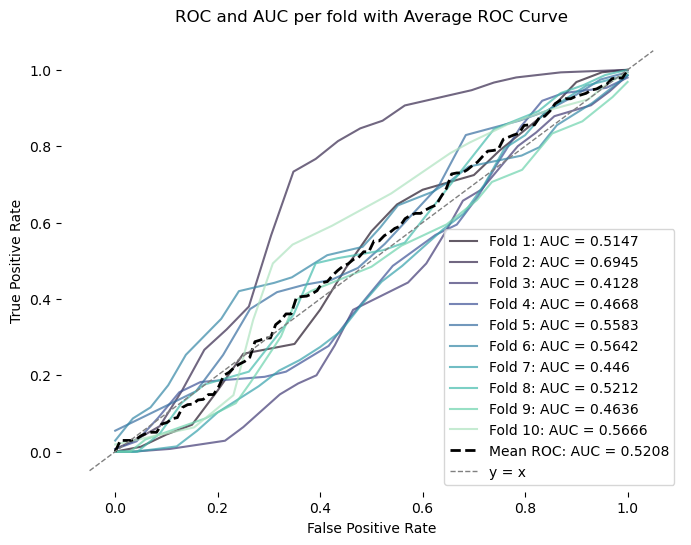

In [18]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(
    fold_results, "mako", "../outputs/auc_financial_crisis_trial1.png", plot_=True
)

#### Trial 2:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 1
- bottom_quartile = 0.25
- top_quartile = 0.75
- metrics = [col for col in df_9c.columns if col.upper() == col]
- list_shift_quarters_for_growth = range(2,9,2) 

In [30]:
crisis_quarter = "2008 Q3"
before_crisis_quarter = "2008 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = range(2, 9, 2)

C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

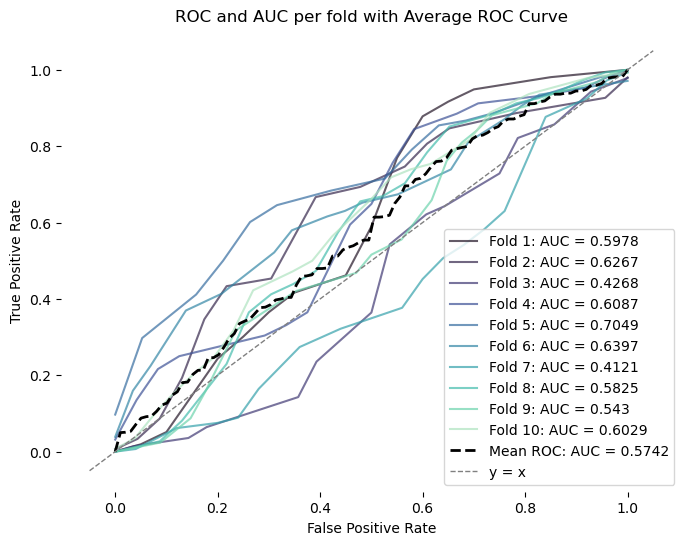

In [31]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial2.png",plot_=True)

#### Trial 3:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 2
- bottom_quartile = 0.25
- top_quartile = 0.75
- metrics = [col for col in df_9c.columns if col.upper() == col]
- list_shift_quarters_for_growth = range(2,9,2) 

In [32]:
crisis_quarter = "2008 Q3"
before_crisis_quarter = "2008 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = range(2, 9, 2)

C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

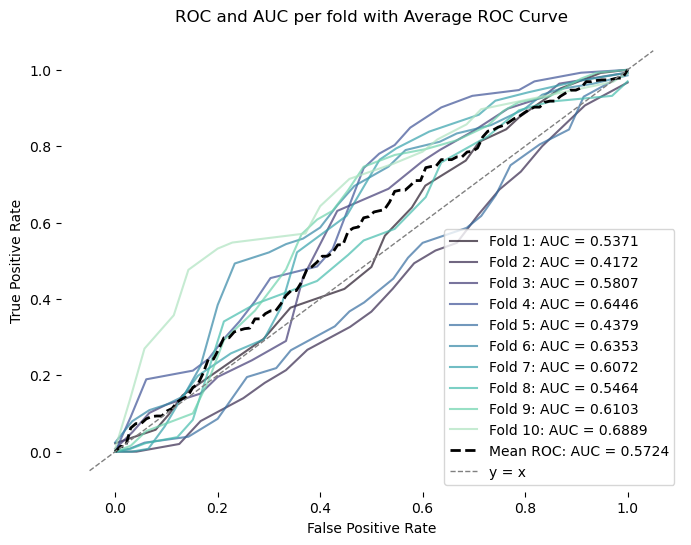

In [33]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial3.png",plot_=True)

#### Trial 4:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 2
- bottom_quartile = 0.25
- top_quartile = 0.75
- metrics = [col for col in df_9c.columns if col.upper() == col]
- list_shift_quarters_for_growth = None

In [34]:
crisis_quarter = "2008 Q3"
before_crisis_quarter = "2008 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = None

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

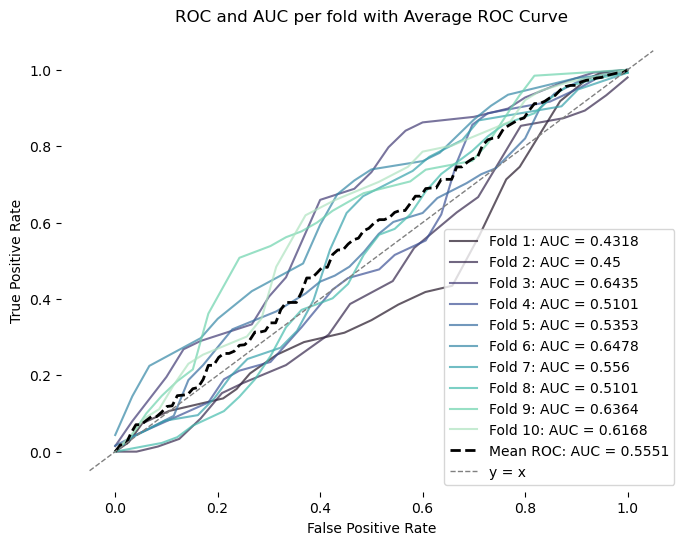

In [35]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial4.png",plot_=True)

## Covid pandemic

#### Trial 1

In [38]:
crisis_quarter = "2021 Q3"
before_crisis_quarter = "2021 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = None

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

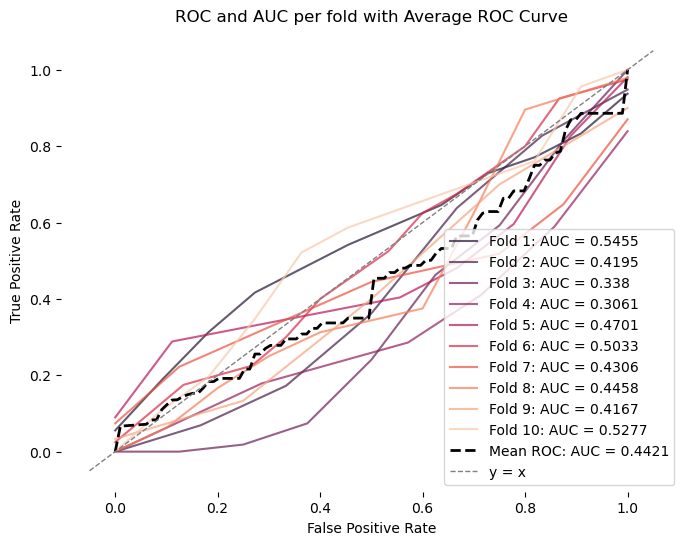

In [39]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial1.png",plot_=True)


#### Trial 2

In [40]:
crisis_quarter = "2021 Q3"
before_crisis_quarter = "2021 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = range(2, 9, 2)

C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

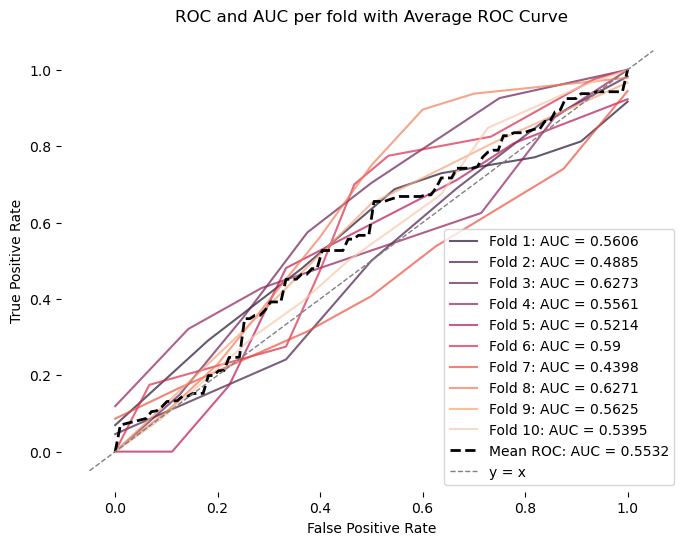

In [41]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial2.png",plot_=True)

#### Trial 3:


In [43]:
crisis_quarter = "2021 Q3"
before_crisis_quarter = "2021 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = range(2, 9, 2)

C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1388435870.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

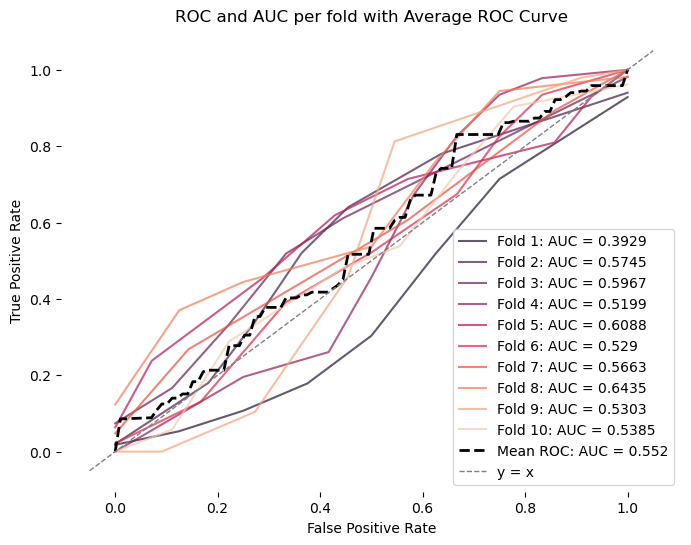

In [44]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial3.png",plot_=True)


#### Trial 4:

In [45]:
crisis_quarter = "2021 Q3"
before_crisis_quarter = "2021 Q2"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
list_shift_quarters_for_growth = None

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

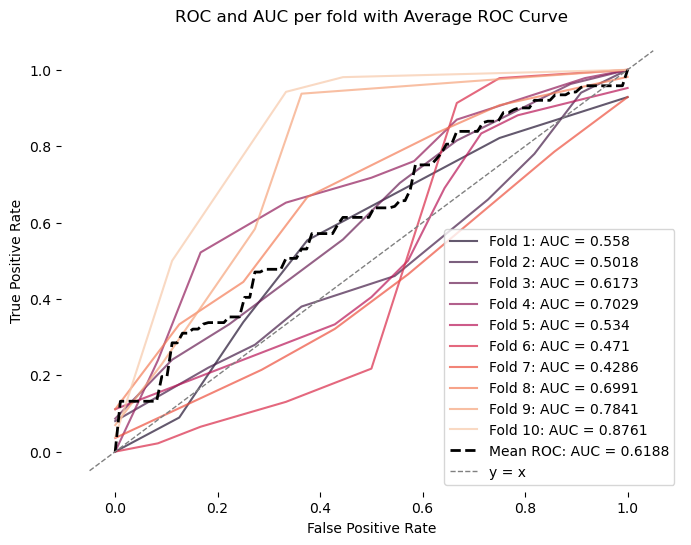

In [46]:
df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=LogisticRegression(penalty=None),
                )
aucs_ = auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial4.png",plot_=True)


## Predictions across multiple periods

In [ ]:
all_quarters_ = df_9c["quarter_code"].unique()

In [ ]:
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c_sorted.columns if col.upper() == col]
list_shift_quarters_for_growth = None


dict_models = {
    "LogisticRegression_nopenalty": LogisticRegression(penalty=None, max_iter=1000),
    "LogisticRegression_l1": LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ),
    "LogisticRegression_l2": LogisticRegression(
        penalty="l2", solver="liblinear", max_iter=1000
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "DecisionTreeClassifier_maxdepth_5": DecisionTreeClassifier(max_depth=5),
    "RandomForestTreeClassifier_nestimators_10": RandomForestClassifier(
        n_estimators=10
    ),
}

list_pipeline_ = []

per_model_results = {}

for model_name, selected_model in dict_models.items():
    per_quarter_predictions = {}
    for crisis_quarter in all_quarters_:
        print(f"model: {model_name}, predicting: {crisis_quarter}")
        per_quarter_predictions_nr_quarters_before_crisis = {}
        for nr_quarters_before_crisis in range(1, 6):

            before_crisis_quarter = shift_quarter_back(
                crisis_quarter, nr_quarters_before_crisis
            )

            if before_crisis_quarter in all_quarters_:

                print(f"nr_quarters_before_crisis: {nr_quarters_before_crisis}")
                df_cv_results, fold_results, df_features, pipeline_ = combine_analysis(
                    data_sorted=df_9c_sorted,
                    crisis_quarter=crisis_quarter,
                    crisis_var=crisis_var,
                    nr_quarters_before_crisis=nr_quarters_before_crisis,
                    bottom_quartile=bottom_quartile,
                    top_quartile=top_quartile,
                    metrics=metrics,
                    list_shift_quarters_for_growth=list_shift_quarters_for_growth,
                    model=selected_model,
                )
                aucs_ = auc_per_fold(
                    fold_results,
                    "mako",
                    "../outputs/auc_financial_crisis_trial1.png",
                    plot_=False,
                )

                list_pipeline_.append(pipeline_)

                per_quarter_predictions_nr_quarters_before_crisis[
                    nr_quarters_before_crisis
                ] = aucs_
        per_quarter_predictions[crisis_quarter] = (
            per_quarter_predictions_nr_quarters_before_crisis
        )
        print("------------")
    per_model_results[model_name] = per_quarter_predictions
    print("------------")

model: LogisticRegression_nopenalty, predicting: 2000 Q1
------------
model: LogisticRegression_nopenalty, predicting: 2000 Q2
nr_quarters_before_crisis: 1
------------
model: LogisticRegression_nopenalty, predicting: 2000 Q3
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
------------
model: LogisticRegression_nopenalty, predicting: 2000 Q4
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
------------
model: LogisticRegression_nopenalty, predicting: 2001 Q1
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
------------
model: LogisticRegression_nopenalty, predicting: 2001 Q2
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: LogisticRegression_nopenalty, predicting: 2001 Q3
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
n

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: LogisticRegression_nopenalty, predicting: 2004 Q1
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: LogisticRegression_nopenalty, predicting: 2004 Q2
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4


c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


nr_quarters_before_crisis: 5
------------
model: LogisticRegression_nopenalty, predicting: 2004 Q3
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5


...

nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier, predicting: 2023 Q3
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier, predicting: 2023 Q4
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier, predicting: 2024 Q1
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier, predicting: 2024 Q2
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier, pred

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier_maxdepth_5, predicting: 2023 Q3
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier_maxdepth_5, predicting: 2023 Q4
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier_maxdepth_5, predicting: 2024 Q1
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: DecisionTreeClassifier_maxdepth_5, predicting: 2024 Q2
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
----

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


------------
model: RandomForestTreeClassifier_nestimators_10, predicting: 2023 Q2
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: RandomForestTreeClassifier_nestimators_10, predicting: 2023 Q3
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: RandomForestTreeClassifier_nestimators_10, predicting: 2023 Q4
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: RandomForestTreeClassifier_nestimators_10, predicting: 2024 Q1
nr_quarters_before_crisis: 1
nr_quarters_before_crisis: 2
nr_quarters_before_crisis: 3
nr_quarters_before_crisis: 4
nr_quarters_before_crisis: 5
------------
model: RandomForestTreeClassifier_nestimators_10, predicting: 2024 Q2
nr_qu

import pickle

# Save dictionary to a pickle file
with open("per_model_results.pkl", "wb") as f:
    pickle.dump(per_model_results, f)


import pickle

In [52]:

# Load it back later
with open("per_model_results.pkl", "rb") as f:
    per_model_results = pickle.load(f)

In [53]:
per_model_pivot_df = {}
for model, data in per_model_results.items():

    rows = []

    for quarter, models in data.items():
        for model_id, folds in models.items():
            # find the "Avg" fold dictionary
            avg_entry = next(x for x in folds if str(x["Fold"]).lower() == "avg")
            rows.append(
                {
                    "crisis_quarter": quarter,
                    "shift_before_crisis_quarter": model_id,
                    "Avg_AUC": avg_entry["AUC"],
                }
            )

    pivot_df = (
        pd.DataFrame(rows)
        .set_index(["crisis_quarter", "shift_before_crisis_quarter"])
        .unstack()
    )
    per_model_pivot_df[model] = pivot_df

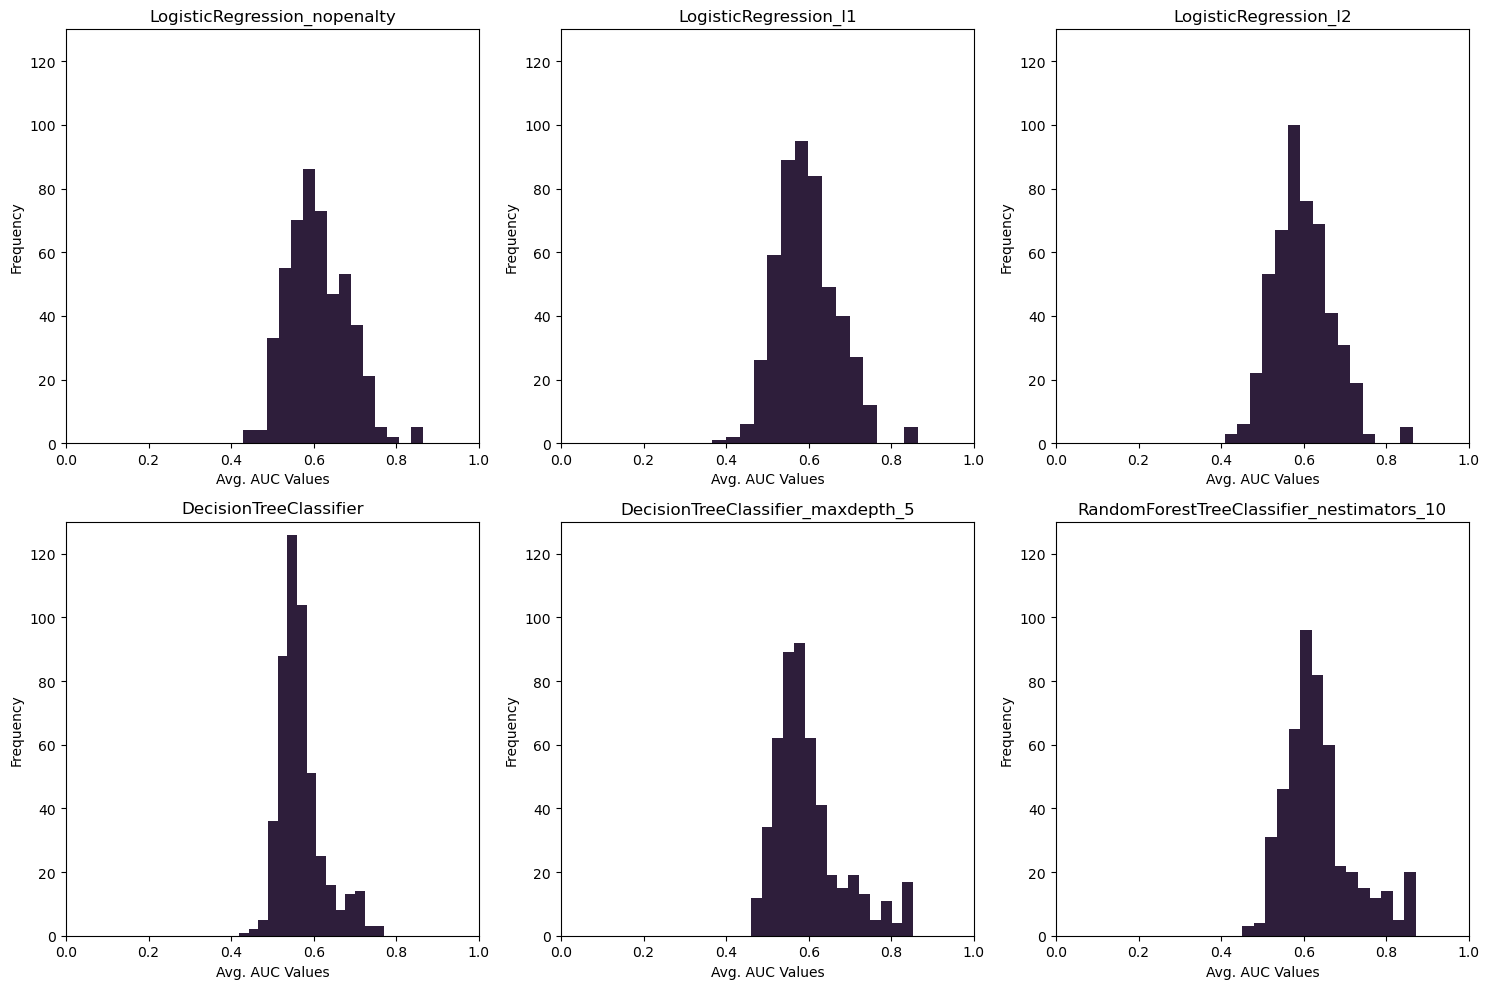

In [56]:
# Compute rows/columns
n_models = len(per_model_pivot_df)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, (key, df) in enumerate(per_model_pivot_df.items()):
    axes[i].hist(
        df.values.flatten(), color=sns.color_palette("mako")[0], bins=15
    )  # optional bins
    axes[i].set_title(key)
    axes[i].set_xlabel("Avg. AUC Values")
    axes[i].set_ylabel("Frequency")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 130)
# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../outputs/histogram_models_auc.png", dpi=300, bbox_inches="tight")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style
sns.set_palette("mako")
colors = sns.color_palette("mako", n_colors=len(per_model_pivot_df))

plt.figure(figsize=(12, 6))

for i, (key, df) in enumerate(per_model_pivot_df.items()):
    values = df.values.flatten()
    sorted_vals = np.sort(values)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    plt.plot(sorted_vals, cdf, label=key, color=colors[i], lw=2)

plt.xlabel("Values")
plt.ylabel("Cumulative Share")
plt.title("CDF of Values per Model")
plt.xlim(0, 1)
plt.ylim(-0.05, 1.05)
plt.legend()
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd

# Start with an empty DataFrame
merged_df = None

for key, df in per_model_pivot_df.items():
    # Reset index to keep row/column as columns
    temp_aux = df.stack().reset_index()
    temp = temp_aux.rename(columns={"Avg_AUC": key})
    if merged_df is None:
        merged_df = temp
    else:
        # Merge on row/column keys
        merged_df = pd.merge(
            merged_df,
            temp,
            on=["shift_before_crisis_quarter", "crisis_quarter"],
            how="outer",
        )

C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\402356751.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_aux = df.stack().reset_index()
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\402356751.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp_aux = df.stack().reset_index()
C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\402356751.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new

In [58]:
from matplotlib.colors import ListedColormap
import seaborn as sns

# 3 colors sampled from mako
mako3 = sns.color_palette("mako", n_colors=4)

# 3 colors sampled from rocket
rocket3 = sns.color_palette("rocket", n_colors=2)

# Combine into one 6-color categorical palette
mako_rocket6 = rocket3 + mako3

# Create ListedColormap
cmap_mako_rocket6 = ListedColormap(mako_rocket6)

C:\Users\joaof\AppData\Local\Temp\ipykernel_22448\1197316729.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("mako", len(unique_models))


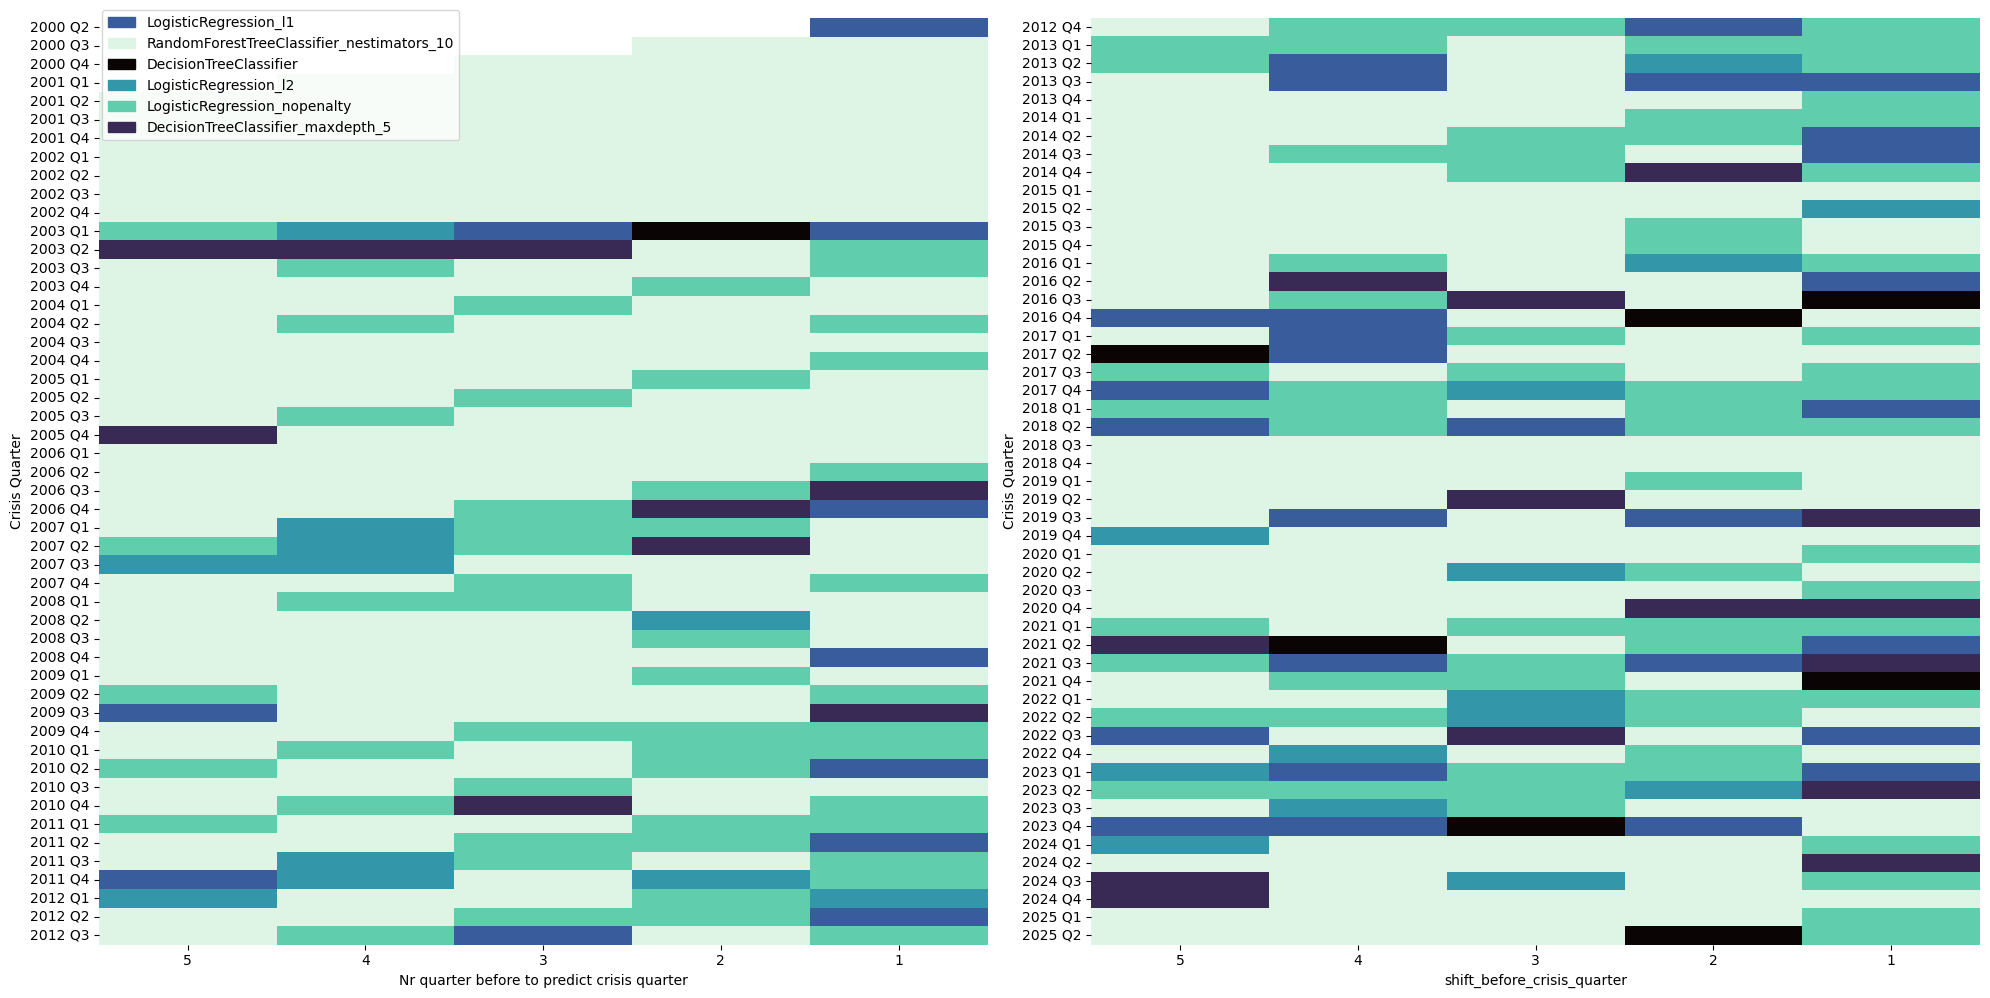

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# your dataframe
df = (
    merged_df.set_index(["crisis_quarter", "shift_before_crisis_quarter"])
    .idxmax(axis=1)
    .sort_index()
    .reset_index()
    .rename(columns={0: "values"})
)

# Convert model names to categorical codes for coloring
df["model_code"] = df["values"].astype("category").cat.codes
model_to_code = dict(zip(df["values"], df["model_code"]))

# Pivot (transposed)
pivot_codes = (
    df.pivot(
        index="shift_before_crisis_quarter",
        columns="crisis_quarter",
        values="model_code",
    )
    .sort_index(ascending=False)
    .T
)

pivot_labels = (
    df.pivot(
        index="shift_before_crisis_quarter", columns="crisis_quarter", values="values"
    )
    .sort_index(ascending=False)
    .T
)

# ---------- SPLIT INTO FIRST 50 ROWS AND REMAINDER ----------
pivot_left = pivot_codes.iloc[:50, :]
pivot_right = pivot_codes.iloc[50:, :]

# ---------- PLOT TWO HEATMAPS SIDE BY SIDE ----------
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.heatmap(pivot_left, fmt="", cmap="mako", cbar=False, ax=axes[0])
# axes[0].set_title("Rows 1–50")
axes[0].set_xlabel("Nr quarter before to predict crisis quarter")
axes[0].set_ylabel("Crisis Quarter")
# axes[0].grid(axis='y', alpha=0.2, color='grey')

sns.heatmap(pivot_right, fmt="", cmap="mako", cbar=False, ax=axes[1])
# axes[1].set_title("Rows 51–End")
# axes[0].set_xlabel("Nr quarter before to predict crisis quarter")
axes[1].set_ylabel("Crisis Quarter")
# axes[1].grid(axis='y', alpha=0.2, color='grey')

# ---------- LEGEND ----------
unique_models = df["values"].unique()
cmap = plt.cm.get_cmap("mako", len(unique_models))

handles = []
for model in unique_models:
    code = model_to_code[model]
    color = cmap(code)
    patch = mpatches.Patch(color=color, label=model)
    handles.append(patch)

fig.legend(
    handles,
    unique_models,
    loc="upper left",
    bbox_to_anchor=(0.05, 1),
)

plt.tight_layout()
plt.savefig("../outputs/models_aucs_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

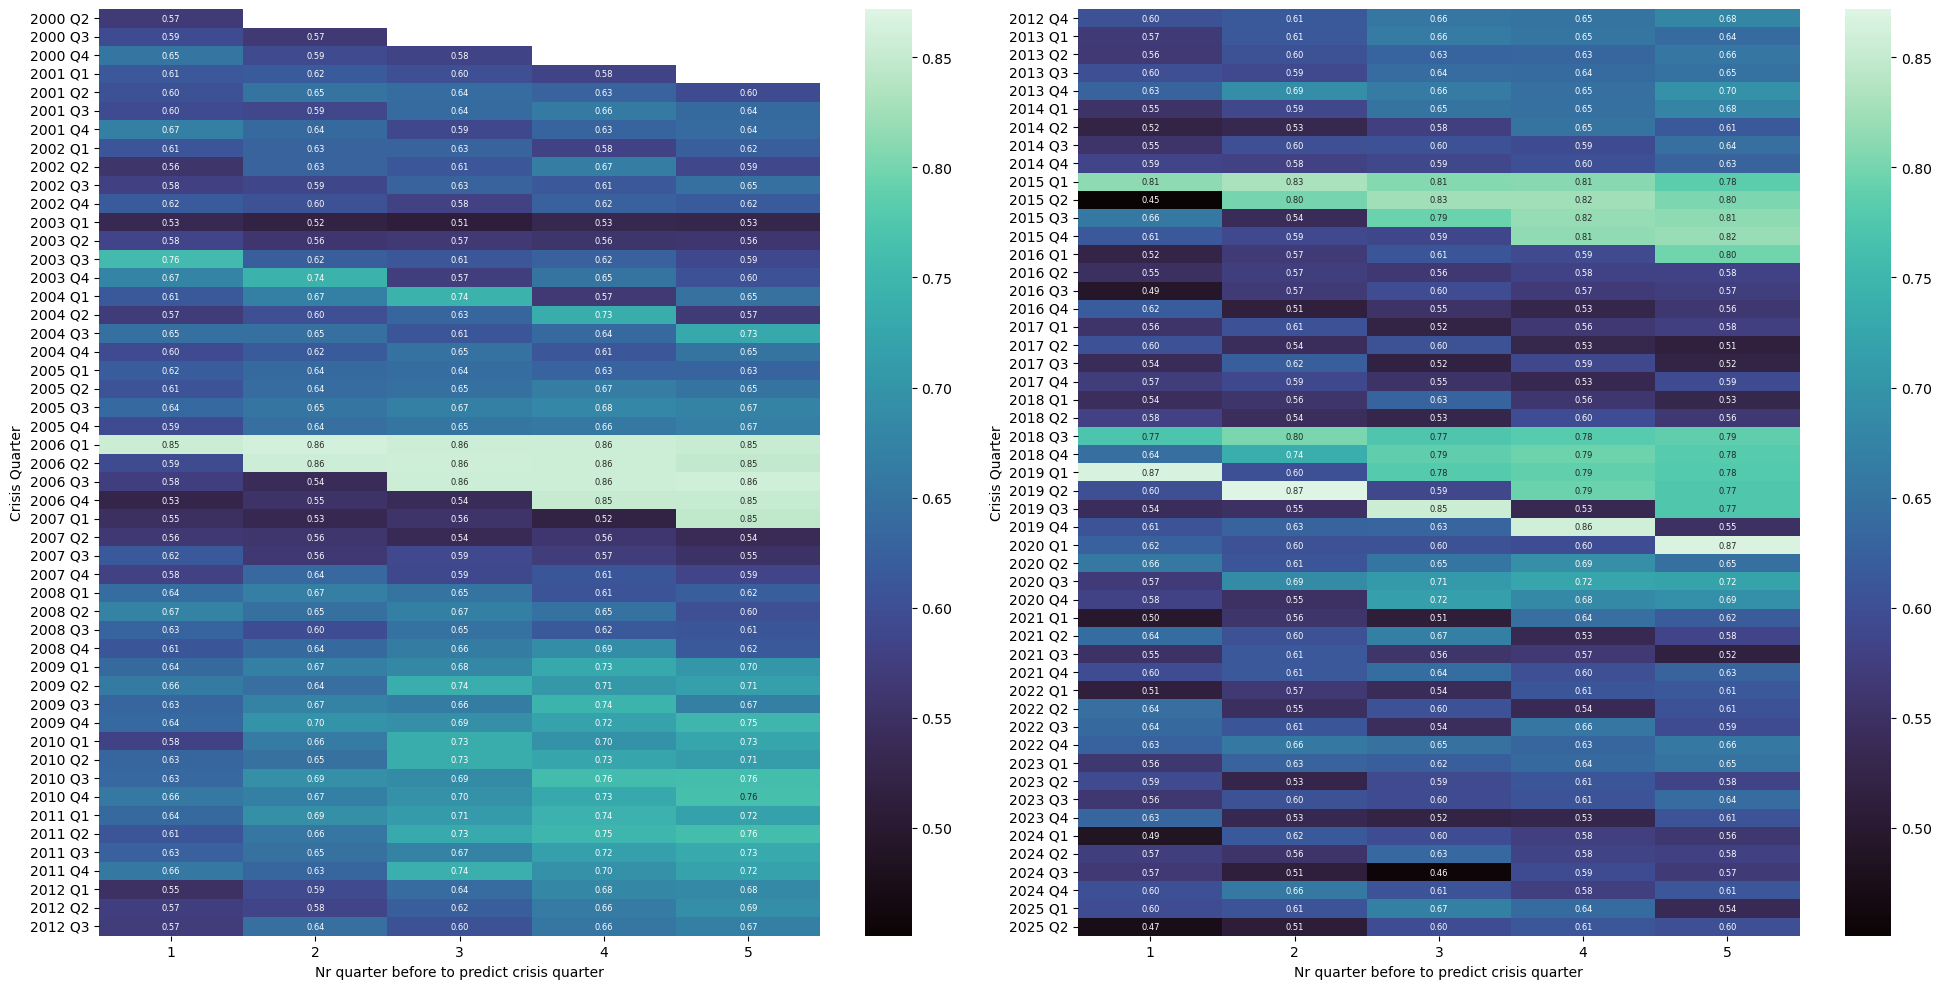

In [60]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
pivot_df = per_model_pivot_df["RandomForestTreeClassifier_nestimators_10"].loc[
    :, "Avg_AUC"
]
vmin = pivot_df.min().min()
vmax = pivot_df.max().max()

sns.heatmap(
    pivot_df.head(50),
    annot=True,
    fmt=".2f",
    cmap="mako",
    annot_kws={"size": 6},
    ax=axes[0],
    vmin=vmin,
    vmax=vmax,
)
sns.heatmap(
    pivot_df.iloc[50:],
    annot=True,
    fmt=".2f",
    cmap="mako",
    annot_kws={"size": 6},
    ax=axes[1],
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_ylabel("Crisis Quarter")
axes[1].set_ylabel("Crisis Quarter")

axes[0].set_xlabel("Nr quarter before to predict crisis quarter")
axes[1].set_xlabel("Nr quarter before to predict crisis quarter")


# plt.sup_title("AUC Heatmap")
plt.tight_layout()

plt.savefig("../outputs/randomforest_aucs_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
df[df["crisis_quarter"] == "2023 Q1"]

In [ ]:
pd.DataFrame(
    zip(df_features.columns, pipeline_.named_steps["model"].coef_[0]),
    columns=["Features", "Coef"],
).assign(AbsCoef=lambda df: df["Coef"].abs()).sort_values(
    "AbsCoef", ascending=False
).head()

## Estimate correlations

In [ ]:
cols_to_consider = [
    col for col in df_new.columns if ("CUMMULATIVE" not in col) and (col.upper() == col)
]


corr = df_new.loc[:, cols_to_consider].iloc[:, 4:].corr().stack().reset_index()
corr.columns = ["var1", "var2", "correlation"]

# Sort variable names in each pair to ignore order
corr[["var1", "var2"]] = corr[["var1", "var2"]].apply(
    lambda row: sorted(row), axis=1, result_type="expand"
)

# Drop duplicates (since now var1-var2 and var2-var1 are the same)
corr = corr.drop_duplicates()

# Remove self-correlations
corr = corr[corr["var1"] != corr["var2"]]

# Optional: filter by threshold
filtered = corr[corr["correlation"] > 0.8]

In [ ]:
corr.sort_values(by="correlation")

In [ ]:
filtered.sort_values(by="correlation")

In [ ]:
df.sort_values(by=["id", "quarter"])